### Building makemore Part 2: MLP [Video Link](https://www.youtube.com/watch?v=TCH_1BHY58I&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=3)

To set up the proper context for the work ahead, I recommend watching the first 2 chapter of the video

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open("names.txt").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
# already covered in the previous notebook, but we repeat here for completeness
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i:s for s,i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset (now using ALL words instead of just the first 5)

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
# 32 examples with 3 character context each
print(X.shape)
print(X.dtype)

# 32 labels, each a single integer (stoi of the next character)
print(Y.shape)
print(Y.dtype)

torch.Size([32, 3])
torch.int64
torch.Size([32])
torch.int64


In [7]:
# the individual examples
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [8]:
# the labels - the next character after the context (this is for the training phase so the model can learn to predict the next character 
# if we show them what the next character is in a real example)
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [9]:
C = torch.randn((27, 2)) # 27 characters in our vocab, 2-dimensional embeddings

In [10]:
C

tensor([[-0.0251, -0.9523],
        [ 0.3080, -0.1831],
        [-0.4696,  0.2059],
        [-0.8534,  0.4732],
        [ 0.2093, -0.7186],
        [-0.7439, -0.8523],
        [-0.3927, -1.4707],
        [ 0.8027, -0.4128],
        [ 0.3012,  0.7047],
        [-0.7604, -2.3598],
        [ 2.0007,  0.1115],
        [ 0.8822, -0.0233],
        [ 0.4923,  1.4774],
        [-1.1097, -0.8529],
        [-1.1419, -0.9820],
        [-1.0829, -2.3014],
        [-0.0666, -0.4970],
        [-1.0690, -0.1333],
        [ 0.5447,  1.3423],
        [-0.1878,  1.2406],
        [-0.5528, -1.3704],
        [-0.4273, -0.4562],
        [ 1.8146, -1.3687],
        [ 0.6524,  0.4635],
        [ 1.7807, -0.1332],
        [ 1.4690,  0.0075],
        [ 0.0918,  1.1651]])

In [11]:
# If we want to get the embedding for a particular character, we can index into C with the integer
# corresponding to that character. For example, if we want the embedding for the character 'e', we would do:
C[5]

tensor([-0.7439, -0.8523])

In [12]:
# Alternatively, we can use one-hot encoding to get the embedding for a character. For example, if we want the embedding for the character 'e', we would do:
# Notice that this outputs the same embedding as C[5] above, because the one-hot matrix for 'e' has a 1 in the 5th position and 0s elsewhere, so when we multiply it by C, we get the 5th row of C.
# Therefore, we will discard this and just use the indexing method to get the embeddings for character in our vocabulary as done above.
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C

tensor([-0.7439, -0.8523])

In [13]:
# We can also get the embeddings for multiple characters at once by indexing into C with a list of integers.
C[[5, 6, 7]]
# We can also use a tensor of integers to index into C
C[torch.tensor([5, 6, 7])]

# We can also repeat the same index multiple times and it'll work fine.
# Here, we are indexing using a 1-D tensor of integers
C[torch.tensor([5, 6, 7, 7, 7])]

tensor([[-0.7439, -0.8523],
        [-0.3927, -1.4707],
        [ 0.8027, -0.4128],
        [ 0.8027, -0.4128],
        [ 0.8027, -0.4128]])

In [14]:
C[X]

tensor([[[-0.0251, -0.9523],
         [-0.0251, -0.9523],
         [-0.0251, -0.9523]],

        [[-0.0251, -0.9523],
         [-0.0251, -0.9523],
         [-0.7439, -0.8523]],

        [[-0.0251, -0.9523],
         [-0.7439, -0.8523],
         [-1.1097, -0.8529]],

        [[-0.7439, -0.8523],
         [-1.1097, -0.8529],
         [-1.1097, -0.8529]],

        [[-1.1097, -0.8529],
         [-1.1097, -0.8529],
         [ 0.3080, -0.1831]],

        [[-0.0251, -0.9523],
         [-0.0251, -0.9523],
         [-0.0251, -0.9523]],

        [[-0.0251, -0.9523],
         [-0.0251, -0.9523],
         [-1.0829, -2.3014]],

        [[-0.0251, -0.9523],
         [-1.0829, -2.3014],
         [ 0.4923,  1.4774]],

        [[-1.0829, -2.3014],
         [ 0.4923,  1.4774],
         [-0.7604, -2.3598]],

        [[ 0.4923,  1.4774],
         [-0.7604, -2.3598],
         [ 1.8146, -1.3687]],

        [[-0.7604, -2.3598],
         [ 1.8146, -1.3687],
         [-0.7604, -2.3598]],

        [[ 1.8146, -1

In [15]:
C[X].shape

# For all of those 32 x 3 embeddings, we have retrieved 32 x 3 x 2 embeddings, which is a 3D tensor.

torch.Size([32, 3, 2])

In [16]:
X[13, 2]

tensor(1)

In [17]:
C[X][13, 2]
# We check for the [13, 2]th example in the dataset, which is the 14th example (since indexing starts at 0). The context for this example is '.', '.', 'a', and the next character is 'v'. We can see that the embedding for the character 'a' (which is at index 2 in the context) is retrieved correctly from C.

tensor([ 0.3080, -0.1831])

In [18]:
C[1]
# We can cross-check that the output for index 1 of C matches the output above.

tensor([ 0.3080, -0.1831])

In [19]:
# therefore, our embeddng matrix will just be C[X]
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [20]:
W1 = torch.randn((6, 100)) # 6 = 3 * 2, because we have 3 characters in the context and each character has a 2-dimensional embedding. 100 is the number of neurons in the hidden layer.
b1 = torch.randn(100) # 100 is the number of neurons in the hidden layer.

In [21]:
# This doesn't work because emb is a 3D tensor and W1 is a 2D tensor. We need to flatten emb into a 2D tensor before we can multiply it by W1. We can do this by using the view method to reshape emb into a 2D tensor with shape (32, 6), where 32 is the number of examples and 6 is the number of features (3 characters * 2 dimensions).
# emb @ W1 + b1

In [22]:
# Here is how view works
a = torch.arange(18)

a = a.view(9, 2)
print(a)
print()
a = a.view(3, 6)
print(a)
print()
a = a.view(3, 3, 2)
print(a)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17]])

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])


In [23]:
# Therefore, we do:
h = emb.view(-1, 6) @ W1 + b1

In [24]:
# The shape is [32, 100], which is what we expect because we have 32 examples and 100 neurons in the hidden layer.
h.shape

torch.Size([32, 100])

In [25]:
# Instead of hardcoding the number of examples (32), we can use -1 to let PyTorch figure out the correct size for that dimension. This is useful if we want to change the number of examples in our dataset later on.
h = emb.view(-1, 6) @ W1 + b1
h
# h remains the same

tensor([[-1.4160, -3.3136, -3.8974,  ...,  2.2229,  0.7225, -0.2547],
        [-1.7547, -2.6148, -4.1943,  ...,  3.0273,  1.0341, -0.7072],
        [-1.8998, -1.8771, -4.7800,  ...,  3.7396,  1.6043, -2.6782],
        ...,
        [-0.5051, -5.3826, -5.0919,  ...,  0.5121,  5.1545, -0.7715],
        [-2.2649, -2.2534, -2.8057,  ...,  2.8454, -1.8598, -2.0035],
        [-1.3548, -0.3138, -3.4424,  ...,  1.8951, -1.3887,  1.0386]])

In [26]:
# Adding a non-linearity to the hidden layer. We will use the tanh function, which squashes the output of the hidden layer to be between -1 and 1. This is important because it allows the model to learn more complex functions and prevents the model from being too sensitive to small changes in the input.
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[-0.8888, -0.9974, -0.9992,  ...,  0.9768,  0.6184, -0.2493],
        [-0.9419, -0.9893, -0.9995,  ...,  0.9953,  0.7755, -0.6089],
        [-0.9562, -0.9542, -0.9999,  ...,  0.9989,  0.9223, -0.9906],
        ...,
        [-0.4661, -1.0000, -0.9999,  ...,  0.4716,  0.9999, -0.6478],
        [-0.9787, -0.9782, -0.9927,  ...,  0.9933, -0.9527, -0.9643],
        [-0.8752, -0.3038, -0.9980,  ...,  0.9558, -0.8829,  0.7773]])

In [27]:
# Adding the final layer to the model. This layer will take the output of the hidden layer (100 neurons)
#  and produce a probability distribution over the 27 characters in our vocabulary. 
# We will use a linear layer followed by a softmax function to produce the probabilities.
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [28]:
# logits are the raw scores for each character in the vocabulary produced by our final layer. 
# We will use these logits to compute the probabilities of each character in the vocabulary using the softmax function.
logits = h @ W2 + b2

In [29]:
logits.shape

torch.Size([32, 27])

In [30]:
# As we saw in the previous notebook, we want to exponentiate our logits first to get the "fake counts" for 
# each character in the vocabulary.
counts = logits.exp()

In [31]:
# Here, we are normalizing the counts by dividing each count by the sum of counts for that example. This will give us a probability distribution over the 27 characters in our vocabulary for each example.
prob = counts / counts.sum(1, keepdims = True)

In [32]:
prob.shape

torch.Size([32, 27])

In [33]:
# We can verify that the probabilities sum to 1 for each example.
prob[0].sum()

tensor(1.)

In [34]:
# Next up we'll be calculating the loss for our model (negative average log likelihood). 
# We'll use the 'Y' from earlier to index into the probabilities and get the probability of the correct character 
# for each example. 
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [35]:
# To index each row, we'll use PyTorch's arange
prob[torch.arange(Y.shape[0]), Y]

tensor([3.0277e-11, 1.6487e-13, 8.1407e-13, 2.5911e-10, 8.9119e-12, 5.1479e-08,
        5.1314e-14, 1.2175e-05, 1.1393e-08, 2.5252e-11, 2.1085e-08, 2.1140e-08,
        9.8672e-07, 7.3724e-07, 3.3008e-03, 3.1812e-08, 1.9577e-01, 7.0250e-10,
        5.0675e-11, 2.3879e-13, 1.8681e-05, 1.2090e-09, 3.1223e-14, 1.9295e-12,
        1.1381e-06, 6.6282e-10, 4.6340e-05, 2.7801e-11, 8.2384e-01, 2.3538e-01,
        1.0936e-03, 1.0055e-15])

In [36]:
# Now we'll compute the loss (negative average log likelihood)
loss = -prob[torch.arange(Y.shape[0]), Y].log().mean()
loss
# The loss is high because our model is currently untrained (random weights & biases).
# It will decrease as we train — correct characters will get higher probabilities.

tensor(18.5544)

In [37]:
X.shape, Y.shape    # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [38]:
# Summarizing the section above.
# Collecting all the parameters of our model into a list for easy access and manipulation.
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator = g)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100, generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn(27, generator = g)

parameters = [C, W1, b1, W2, b2]

In [39]:
sum(p.nelement() for p in parameters)   # number of parameters in total

3481

In [40]:
emb = C[X]  # (N, 3, 2) tensor of embeddings for each character in the context of each example (N = total examples)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)   # (N, 100) tensor of hidden layer activations for each example
logits = h @ W2 + b2   # (N, 27) tensor of logits for each example
# counts = logits.exp()
# prob = counts/counts.sum(1, keepdims = True)
# loss = -prob[torch.arange(Y.shape[0]), Y].log().mean()

# The three commented lines above (they were also used in the previous video):
# counts = logits.exp()
# prob = counts/counts.sum(1, keepdims = True)
# loss = -prob[torch.arange(32), Y].log().mean()
# can be merged into a single line of code as shown below using PyTorch's cross_entropy funtion (and ofc the output will be the same in case if you uncomment the lines above):
loss = F.cross_entropy(logits, Y)
loss

tensor(17.7697)

Why F.cross_entropy() is better than the manual approach:

##### 1) Forward pass: Numerical stability via the LogSumExp trick

The manual approach does: `logits.exp() -> counts / counts.sum() -> -log(probs[Y]).mean()`

**Problem**: If any logit is large (e.g., 100), `logits.exp()` produces a huge number (e^100 ≈ 2.7e43), which can overflow to inf. Conversely, if logits are very negative (e.g., -100), `exp(-100) ≈ 3.7e-44`, which underflows to 0, making `log(0) = -inf` and breaking the loss entirely.

`F.cross_entropy()` internally uses the **LogSumExp trick**:

    log(Σ e^x_i) = max(x) + log(Σ e^(x_i - max(x)))

It subtracts the maximum logit from **all** logits BEFORE exponentiating, so the largest exponentiated value becomes e^0 = 1, and all others are fractions. This guarantees no overflow.

**Concrete example**:

    logits = [50, 45, 52, 48]  (max = 52)
    Manual: exp(52) ≈ 3.8e22  →  large but okay, but scale up and it breaks.
    F.cross_entropy: x_i - max = [-2, -7, 0, -4]
      → exp([-2, -7, 0, -4]) = [0.135, 0.0009, 1.0, 0.018]
      → safe, no overflow.

##### 2) Backward pass: Analytically simpler & cheaper

The gradient of cross-entropy loss w.r.t. logits has a beautiful closed form:

    dL/d(logit_k) = softmax(logits)[k] - (1 if k == target_class else 0)

i.e., it's just `(predicted_probability - target_one_hot)` for each class.

If you manually decompose it into: `exp → sum → divide → log → mean`, autograd has to chain gradients through each intermediate node in the computation graph. This uses more memory (saving all intermediate activations for backprop) and more compute.

`F.cross_entropy()` fuses the softmax and negative log-likelihood loss into a single operation with a bespoke backward kernel, so no intermediate tensors are saved and the gradient is computed directly. **Faster + less memory**.

##### 3) Numerically superior gradient computation

The manual approach computes: `prob = softmax(logits)`, then `loss = -log(prob[target])`. The gradient w.r.t. logits becomes: `dL/d(logit_k) = prob[k] - (k == target)`.

BUT: if `prob[target]` is very small (the model is very wrong), `-log(prob[target])` is large, and floating-point precision can suffer. `F.cross_entropy()` computes log-softmax directly (without materializing probabilities first) and then applies NLLLoss, so it never has to store or differentiate through the intermediate probability tensor. This avoids precision loss at extreme values.

##### Summary

| Aspect                | Manual (exp → sum → log) | F.cross_entropy()  |
|-----------------------|--------------------------|--------------------|
| Numerical stability   | Can overflow/underflow   | Stable (LSE trick) |
| Forward compute       | 4 separate ops           | 1 fused op         |
| Backward compute      | Full autograd chain      | Direct gradient    |
| Memory                | Saves intermediates      | Fused, less memory |
| Gradient precision    | Subject to float error   | More accurate      |

**Bottom line**: Always use `F.cross_entropy(logits, targets)` unless you need the probabilities explicitly for something else. It's faster, more memory-efficient, numerically stable, and the gradient is more accurate.

In [41]:
# We need to explicitly tell PyTorch that we want to compute gradients with respect to these parameters during backpropagation. 
# We do this by setting the `requires_grad` attribute of each parameter tensor to `True`. 
# This allows PyTorch to track operations on these tensors and compute gradients during the backward pass.
for p in parameters:
    p.requires_grad = True

In [42]:
# implementing the training loop for our model
for _ in range(10):
    # forward pass
    emb = C[X]  
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)   
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
        
print(loss.item())

# The loss is so low because we are only currently fitting 32 examples. 
# This is called overfitting because we have so many parameters in our model, that is, our model is complicated enough 
# but the input data is too small, that it can memorize the training data and produce a very low loss.

4.414664268493652


In [43]:
# The loss is not 0 because as you notice from the logits vs Y comparison, the first indice from 
# logits.max (which is 19) vs Y (5) is why one of the instances why our loss is not 0. 
# This is because when the context is '...', the first character from our input data can be 'e' (5), or even 'a' (1),
# or even 'o' (15). 
# Therefore, our model was able to overfit, but not extremely overfit where it was able to correctly guess the 
# first character of a word when the context is '...'.

logits.max(1)

torch.return_types.max(
values=tensor([10.7865, 12.2558, 17.3982, 13.2739, 10.6965, 10.7865,  9.5145,  9.0495,
        14.0280, 11.8378,  9.9038, 15.4187, 10.7865, 10.1476,  9.8372, 11.7660,
        10.7865, 10.0029,  9.2940,  9.6824, 11.4241,  9.4885,  8.1164,  9.5176,
        12.6383, 10.7865, 10.6021, 11.0822,  6.3617, 17.3157, 12.4544,  8.1669],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1,  8,  9,  0, 15,  1, 17,  2,  9,  9,  2,  0,  1, 15,  1,  0,  1, 19,
         1,  1, 16, 10, 26,  9,  0,  1, 15, 16,  3,  9, 19,  1]))

In [44]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

#####                                                           ---------------- Can be considered a check-point -----------------

In [45]:
# building the dataset on all of the words in the names.txt file now, not just the first 5 words

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [46]:
X.shape, Y.shape    # dataset

# so now we have 228146 examples instead of just 32.

(torch.Size([228146, 3]), torch.Size([228146]))

In [71]:
# re-initializing the weights and biases
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [72]:
for p in parameters:
    p.requires_grad = True

In [49]:
for _ in range(10):
    # forward pass
    emb = C[X]  
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

# this takes a while to run because we are training on 228146 examples at once.


26.00634002685547
24.33698081970215
22.652690887451172
21.396020889282227
21.29038429260254
20.23537254333496
19.252534866333008
18.55494499206543
18.0413761138916
17.525545120239258


In [50]:
# to address that issue, we use mini-batches
# below is a use-case of randint in Pytorch for generating random indices to create mini-batches of data for training. This allows us to train the model on smaller subsets of the data at a time, which can help with convergence and reduce memory usage.
torch.randint(0, X.shape[0], (32,))

# below are indice examples that are generated randomly for creating mini-batches of data for training. Each time you run this code, you will get different random indices (random examples).

tensor([ 70139, 126408,  42247,  76916, 149919,  78907, 212120, 205978, 208349,
        171028,  77071, 212073,  93117, 175948,  12035, 140870,  51133, 143924,
        161449, 171435,  16574,  78597, 210465, 148598,  26725, 161050, 185521,
         51622, 180597, 125800, 214134, 123103])

In [ ]:
# with mini-batches
lri = []
lossi = []

for i in range(10000):
    
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]  
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

# print(loss.item())

# with mini-batches, the gradient direction is not the best compared to the whole dataset pass but we still prefer
# this over increased time that comes with passing the entire dataset
# Therefore, it is much better to take more steps with approximate gradient, then to take fewer steps with exact gradient.

# Edit 1: Changed no.of iterations from 1000 to 10000 after setting the suitable learning rate. Know more about this down below.
# Edit 2: Changed the learning rate from 0.1 (the suitable one) to 0.01 after 3*10000 iterations - Loss at this stage was: 2.3544. This is called learning rate decay. People often decrease the learning rate by a factor of 10 when they feel like the loss is plateauing after a bunch of initial iterations. loss at this stage was: 2.1963 just after 1 * 10000 iterations; loss after 3*10000 iterations with decayed learning rate: 2.1879.

# Note: The loss of the bigram character level model from the previous video was 2.45. The loss for this model currently is 2.18. Therefore, we have already achieved lesser loss with this model.

In [85]:
# the loss above is only for the mini-batch
# the loss below is for the entire model
emb = C[X]  
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.1879, grad_fn=<NllLossBackward0>)

In [ ]:
# One thing to consider is "what the right learning rate is?". We used 0.1 in our case but that was just an estimate. 
# Let's now find the suitable learning rate for our case.
# We can use .linspace from PyTorch which generates 100 numbers b/w 0.001 and 1 with equal intervals in this example below.
linear_lr = torch.linspace(0.001, 1, 1000)
print(here)
# But this is linear. We want learning rate exponent
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre      # 10**-3 = 0.001 and 10*0 = 1, so this 
lrs

# Now updating the constant learning rate in the training loop above with this concept.
# Commented after I found out the best learning rate from the graph below.


tensor([0.0010, 0.0020, 0.0030, 0.0040, 0.0050, 0.0060, 0.0070, 0.0080, 0.0090,
        0.0100, 0.0110, 0.0120, 0.0130, 0.0140, 0.0150, 0.0160, 0.0170, 0.0180,
        0.0190, 0.0200, 0.0210, 0.0220, 0.0230, 0.0240, 0.0250, 0.0260, 0.0270,
        0.0280, 0.0290, 0.0300, 0.0310, 0.0320, 0.0330, 0.0340, 0.0350, 0.0360,
        0.0370, 0.0380, 0.0390, 0.0400, 0.0410, 0.0420, 0.0430, 0.0440, 0.0450,
        0.0460, 0.0470, 0.0480, 0.0490, 0.0500, 0.0510, 0.0520, 0.0530, 0.0540,
        0.0550, 0.0560, 0.0570, 0.0580, 0.0590, 0.0600, 0.0610, 0.0620, 0.0630,
        0.0640, 0.0650, 0.0660, 0.0670, 0.0680, 0.0690, 0.0700, 0.0710, 0.0720,
        0.0730, 0.0740, 0.0750, 0.0760, 0.0770, 0.0780, 0.0790, 0.0800, 0.0810,
        0.0820, 0.0830, 0.0840, 0.0850, 0.0860, 0.0870, 0.0880, 0.0890, 0.0900,
        0.0910, 0.0920, 0.0930, 0.0940, 0.0950, 0.0960, 0.0970, 0.0980, 0.0990,
        0.1000, 0.1010, 0.1020, 0.1030, 0.1040, 0.1050, 0.1060, 0.1070, 0.1080,
        0.1090, 0.1100, 0.1110, 0.1120, 

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

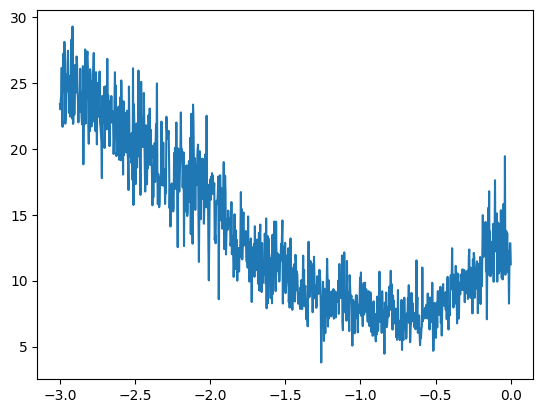

In [ ]:
# plotting the graph with lre and loss to find out the suitable learning rate
# x axis - exponent of the learning rate
# y axis - loss

plt.plot(lri, lossi)

# We can notice that exponent being roughly around -1 is the best setting, i.e., 10^-1 = 0.1 is the best learning rate. That is what we initially had by coincidence

In [ ]:
# We cannot judge the model entirely based on its loss. A loss of 0 sounds good but it means that the model overfits the entire dataset. 
# It memorizes the dataset. A complex model with more parameters (in our case, we have 3481), like 10000 or 100000 for example could help the 
# model overfit, i.e., memorize the dataset better. So we need to split our dataset into 3 categories. 

# We need to split the dataset into:
# - Training Set: Usually around 80%; Used to optimize the parameters of the model
# - Dev/Validation Set: Usually around 10%; Used for development of all the hyperparameters of the model, for example, the size of the hidden layer, the size of the embedding, the strength of regularization (which we haven't used. We have 100 neurons in the hidden layer, so we can use this subset of data to tweak and test those out.
# - Testing Set Usually around 10%; Used to evaluate the performance of the model at the end. We only run our model on this dataset very very few times (ideally once at the end), otherwise, we risk overfitting our testing dataset as well.

# Therefore, building the dataset now results in:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

# The output here are the number of individual examples made from those words.

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
print(n1)                   # We have n1 (80%) training examples - 25626 words from names.txt
print(n2 - n1)              # We have n2 - n1 (10%) dev/validation examples - 3203 words
print(len(words) - n2)      # And we have 3204 test examples

25626
3203
3204


In [ ]:
Xtr.shape, Ytr.shape       # training data

(torch.Size([182625, 3]), torch.Size([182625]))

In [145]:
# resetting the network. we could have also run these 3 code block above and came back here, but i have added this here again just for clarity and convenience.
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

# Edit 1: Expanding the hidden layer by adding more no.of neurons from 100 to 300.
# Edit 2: Changed the no.of neurons in the hidden layer from 300 to 200 AND Changed the dimension size of the embeddings from 2 to 10.

In [146]:
sum(p.nelement() for p in parameters)

11897

In [147]:
for p in parameters:
    p.requires_grad = True

In [148]:
lri = []
lossi = []
stepi = []

In [161]:
for i in range(200000):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]  
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

# Initial 1: Ran 30000 iterations with learning rate of 0.1 and 10000 with learning rate of 0.01 (learning rate decay)

# Edit 1: Changed the no.of iterations to 200,000 and if statement with lr = 0.1 for under 100,000 iterations and then lr = 0.01

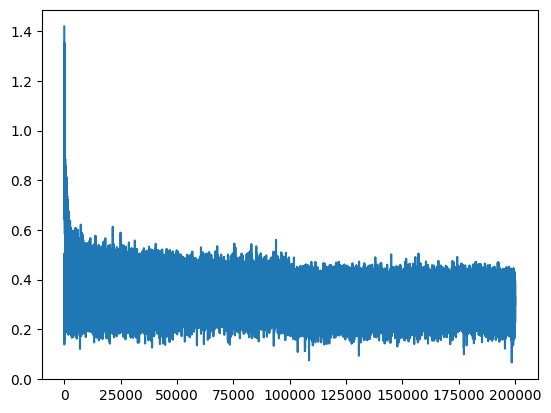

In [162]:
plt.plot(stepi, lossi)

In [163]:
# Evaluating the model using the dev dataset here. Remember, this is the first time model is seeing the dev dataset examples. The loss is 2.2343 (this was with different parameter settings I didnt pay attention to - 10 embedding size and 200 neurons coming up down below).
emb = C[Xdev]  
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1494, grad_fn=<NllLossBackward0>)

In [164]:

emb = C[Xtr]  
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

# The loss of the model on the entire training dataset was 2.2124.
# We can notice that the losses for the training dataset and the dev/validation dataset were almost identical, so we were not overfitting.
# The model is not complex enough with 3481 parameters, i.e., the network is tiny. We are under-fitting - the network is not complex enough to learn patterns. 
# We expect to increase the performance of the neural network by increasing the size of the neural net. One way to do that is expand the hidden tanh layer by adding more no.of neurons above.

tensor(2.0980, grad_fn=<NllLossBackward0>)

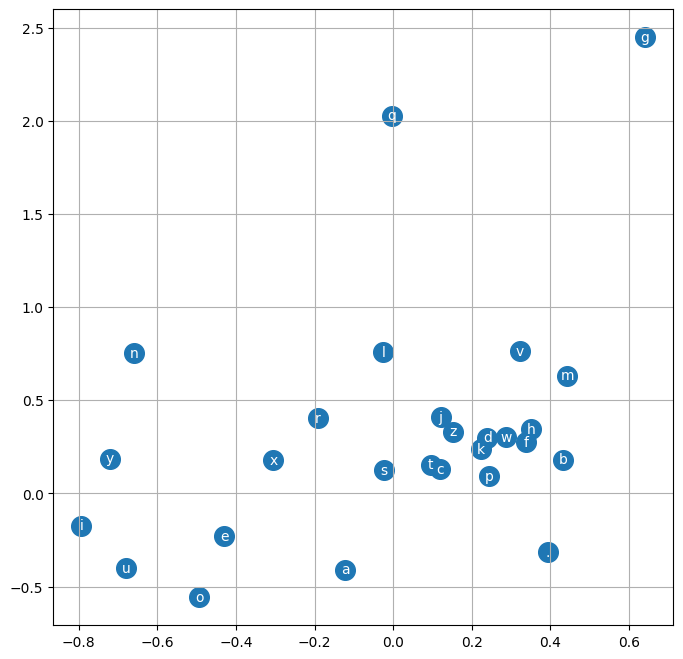

In [ ]:
# As you can notice from above, the loss is 2.2464 for dev set and 2.2373 from training set after a bunch of steps. We are not improving much after and so, maybe the bottleneck is character embedding size which is 2.

# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

# The network has learned to seperate out the characters and cluster them up a bit. You can notice how the vowels - a,e,i,o,u are clustered up close to each other. So the neural network learned that they are similar to each other and can often be used interchangebly.
# It's interesting that there is a little bit of a structure here because it's definetely not random and the model has learned something here.
# It is possible to memorize here since the size of the embeddings is just 2, so we can scale them on the x and the y axis, but now when we change the size of the embeddings in order to increase the size of the neural net, it'll be hard to visualize them like down below.


In [165]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahzate.
heri.
kemri.
reety.
skanden.
jazonte.
deliah.
jagqui.
nellara.
chaiir.
kaleigphilma.
din.
quinn.
sulin.
alianni.
wazell.
dearyxiani.
eveighan.
eddeciic.
gianahya.
